# L05 - Position of a star
## You measure the position of a star  N  times with the same telescope 

# Part 1
Errors are homoscedastic. The underlying process is gaussian. The true position $\mu=1$ and the essors are $\sigma=0.2$
- Generate fake measurements
- Treat each of these observations as an estimate of the true distribution.
- The probability of each data point is a Gaussian (with the known sigma) centered at each point.
- Plot each of the individual likelihoods separately and their product (the likelihood of the dataset) 
- Make sure the x grid has enough points
- Just read off the maximum likelihood solution (e.g. using np.argsort)
- Compare it with the MLE estimator

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
mu = 1.0
sigma = 0.2
N = 50

data = np.random.normal(mu, sigma, N)
mu_grid = np.linspace(-0.3, 2.3, 100000)
likelihoods = []
for xi in data:
    L = (1/(np.sqrt(2*np.pi)*sigma) * np.exp(-(xi-mu_grid)**2/(2*sigma**2)))
    likelihoods.append(L/np.max(L))

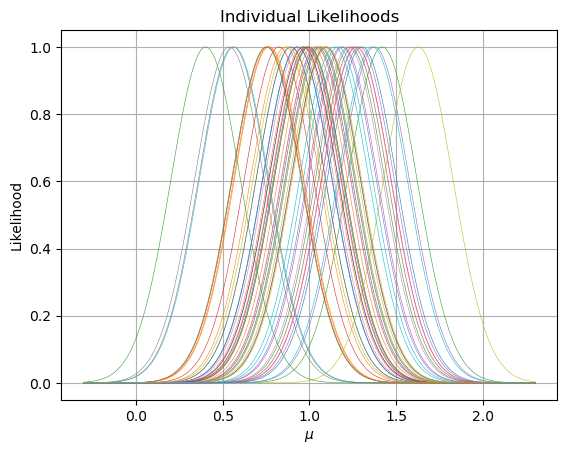

In [9]:
for i,L in enumerate(likelihoods):
    plt.plot(mu_grid, L, lw=0.4) 

plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Individual Likelihoods')
plt.grid()
plt.show()

In [10]:
L_tot = np.ones_like(mu_grid)
for L in likelihoods:
    L_tot *= L

L_tot /= np.max(L_tot)

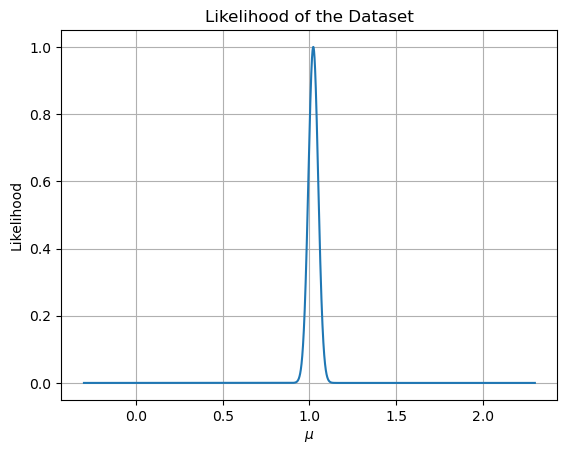

In [11]:
plt.plot(mu_grid, L_tot)
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Likelihood of the Dataset')
plt.grid()
plt.show()

In [12]:
# MLE 
idx_max = np.argmax(L_tot)
numerical_ML = mu_grid[idx_max]
theoretical_ML = np.mean(data)

print(f"Numerical MLE = {numerical_ML:.6f}")
print(f"Theoretical MLE = {theoretical_ML:0.6f}")

Numerical MLE = 1.022347
Theoretical MLE = 1.022343


## Part 2
Do a rough 2nd order differentation of our log-likelihood function \
Divide through by our Δmu^2 to get the correct normalization \
Multiply by -1 \
Taken the square root \
Compare with the Fisher matrix error \
Plot a Gaussian at the measured mu with this error as the scale to see if it matches the numerical likelihood distribution.

In [15]:
logL = np.zeros_like(mu_grid)
for L in likelihoods:
    logL += np.log(L)

dmu = mu_grid[1]-mu_grid[0]
d2logL = np.diff(logL, n=2) / dmu**2

mu_mid=mu_grid[1:-1]
idx_max_d2 = idx_max-1

numerical_Fisher_sigma = 1/np.sqrt(-1*d2logL[idx_max-1])
thoretical_Fisher_sigma = sigma/np.sqrt(N)

print(f"Numerical Fisher Sigma = {numerical_Fisher_sigma}")
print(f"Theoretical Fisher Sigma = {thoretical_Fisher_sigma}")

#check
#print(d2logL[idx_max_d2])
#print(mu_grid.shape)
#print(d2logL.shape)

Numerical Fisher Sigma = 0.02828427186100738
Theoretical Fisher Sigma = 0.0282842712474619


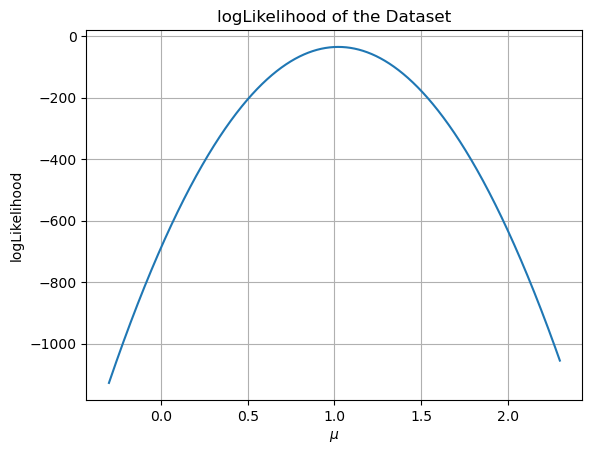

In [16]:
plt.plot(mu_grid, logL)
plt.xlabel(r'$\mu$')
plt.ylabel('logLikelihood')
plt.title('logLikelihood of the Dataset')
plt.grid()
plt.show()

## Part 3 - heteoscedastic errors
 Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean 0.2 and standard deviation 0.05. \
 Generalize your code from above to this case

In [17]:
sigma_i = np.abs(np.random.normal(0.2, 0.05, N))
x_i = np.random.normal(mu, sigma_i)
mu_grid = np.linspace(-0.3, 2.3, 100000)

likelihoods_het = []
for xi, si in zip(x_i, sigma_i):
    L_i = (1/(np.sqrt(2*np.pi)*si) * np.exp(-(xi-mu_grid)**2/(2*si**2)))
    likelihoods_het.append(L_i/np.max(L_i))

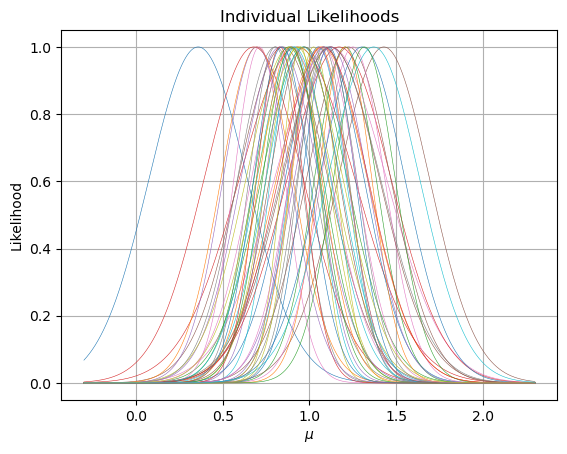

In [19]:
for i,L in enumerate(likelihoods_het):
    plt.plot(mu_grid, L, lw=0.4) 

plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Individual Likelihoods')
plt.grid()
plt.show()

In [20]:
L_tot_het = np.ones_like(mu_grid)
for L in likelihoods_het:
    L_tot_het *= L

L_tot_het /= np.max(L_tot_het)

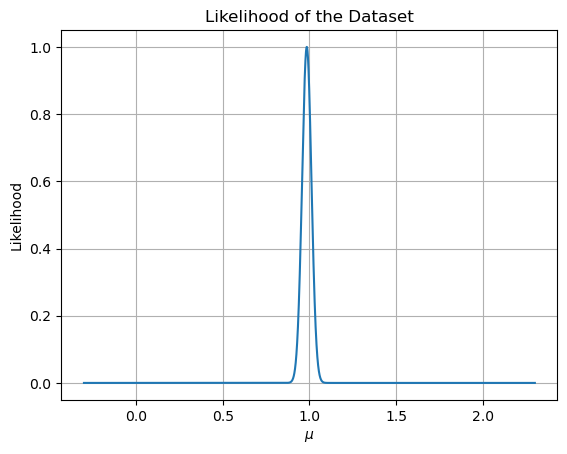

In [21]:
plt.plot(mu_grid, L_tot_het)
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Likelihood of the Dataset')
plt.grid()
plt.show()

In [22]:
# MLE 
idx_max_het = np.argmax(L_tot_het)
numerical_ML_het = mu_grid[idx_max_het]
theoretical_ML_het = np.sum(x_i/sigma_i**2)/np.sum(1/sigma_i**2)

print(f"Numerical MLE = {numerical_ML_het:.6f}")
print(f"Theoretical MLE = {theoretical_ML_het:0.6f}")

Numerical MLE = 0.984855
Theoretical MLE = 0.984861


In [23]:
logL_het = np.zeros_like(mu_grid)
for L in likelihoods_het:
    logL_het += np.log(L)

dmu = mu_grid[1]-mu_grid[0]
d2logL_het = np.diff(logL_het, n=2) / dmu**2

mu_mid=mu_grid[1:-1]
idx_max_het_d2 = idx_max_het-1

numerical_Fisher_sigma_het = 1/np.sqrt(-1*d2logL_het[idx_max_het_d2-1])
theoretical_Fisher_sigma_het = 1/np.sqrt(np.sum(1/sigma_i**2))

print(f"Numerical Fisher Sigma = {numerical_Fisher_sigma_het}")
print(f"Theoretical Fisher Sigma = {theoretical_Fisher_sigma_het}")

Numerical Fisher Sigma = 0.0269350682866834
Theoretical Fisher Sigma = 0.026935068032810597


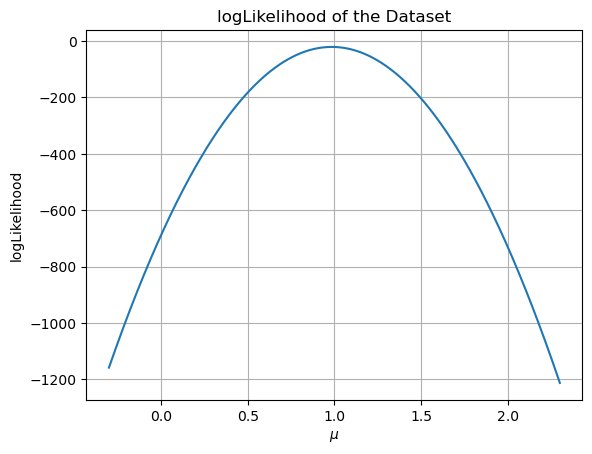

In [24]:
plt.plot(mu_grid, logL_het)
plt.xlabel(r'$\mu$')
plt.ylabel('logLikelihood')
plt.title('logLikelihood of the Dataset')
plt.grid()
plt.show()